<style>
:root { --navy:#17324D; --teal:#2A9D8F; --red:#C94F55; --green:#4E9F70; }
h1, h2, h3 { color: var(--navy); }
h1 { border-left: 8px solid var(--teal); padding-left: 14px; }
h2 { border-bottom: 2px solid var(--teal); padding-bottom: 6px; }
blockquote { border-left: 5px solid var(--red); background:#FFF4D6; padding:12px 18px; }
.callout { background:#EAF3F7; border-left:5px solid var(--teal); padding:12px 18px; margin:12px 0; }
.warning { background:#FFF4D6; border-left:5px solid var(--red); padding:12px 18px; margin:12px 0; }
</style>

# Chronic Kidney Disease

## Was fehlende Werte über ein Modell verraten

**Data-Analytics-Projekt mit Random Forest, logistischer Regression und Leave-One-Out-Cross-Validation**

**Natasza Szczypien · September 2026**

---

### Leitfrage

Wie gut lässt sich CKD innerhalb dieses Datensatzes klassifizieren und welchen Anteil daran haben medizinische Messwerte beziehungsweise Muster fehlender Untersuchungen?

## Kurzfassung

Die Analyse begann als klassische Vorhersageaufgabe. Während der explorativen Datenanalyse zeigte sich jedoch ein zentrales Datenqualitätsproblem: Fehlende Werte sind stark mit dem CKD-Status verbunden.

Das verändert die Fragestellung. Ein Modell kann nicht nur medizinische Krankheitsmuster lernen. Es kann zusätzlich erkennen, **wie die Untersuchungen dokumentiert wurden**.

Die wichtigsten Ergebnisse:

- 400 Patienten, davon 250 mit CKD und 150 ohne CKD
- nur 158 vollständige Fälle
- 82,8 % der CKD-Fälle, aber nur 23,3 % der Non-CKD-Fälle sind unvollständig
- Fisher-Exakt-Test: `p = 6,65 × 10⁻³³`
- vollständige Modelle erreichen intern 98,4 % bis 100 % Balanced Accuracy
- ein Modell allein aus Missing-Indikatoren erreicht bereits 83,3 % Balanced Accuracy

<div class="warning"><b>Kernaussage:</b> Die Modelle erkennen ein starkes medizinisches Signal. Gleichzeitig nutzen sie ein datensatzspezifisches Dokumentationsmuster. Die sehr gute interne Leistung belegt deshalb keine Übertragbarkeit auf andere Kliniken.</div>

## 1. Datenquelle und Reproduzierbarkeit

Der Datensatz **Chronic Kidney Disease** stammt aus dem UCI Machine Learning Repository.

- DOI: https://doi.org/10.24432/C5G020
- 400 Patientenbeobachtungen
- 24 Eingabeparameter
- Zielvariable: `ckd` oder `notckd`
- Lizenz: **CC BY 4.0**

Das Notebook lädt die mitgelieferte CSV-Datei. Alternativ kann die Funktion `load_ckd_dataset()` den Datensatz mit `ucimlrepo` beziehen.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

import ckd_report_functions as ckd

ckd.set_report_style()

DATA_PATH = Path("chronic_kidney_disease.csv")
data_raw, classes_raw, parameter_information = ckd.load_ckd_dataset(DATA_PATH)
data, classes = ckd.clean_ckd_data(data_raw, classes_raw)
y = ckd.encode_target(classes)

total, complete, incomplete = ckd.split_by_completeness(data)

print(f"Geladen: {len(total)} Patienten mit {total.shape[1]} Eingabeparametern")

Geladen: 400 Patienten mit 24 Eingabeparametern


## 2. Technische Grundbereinigung

Die Rohdaten bleiben unverändert. Für die Analyse wird eine bereinigte Kopie verwendet.

Geprüft wurden:

- Schreibvarianten und unsichtbare Leerzeichen
- Tabulatoren wie `"\tno"` in `dm`
- Fragezeichen und leere Zeichenketten als fehlende Werte
- numerische Datentypen
- Zielklassen
- vollständig identische Zeilen

Es werden keine medizinischen Extremwerte automatisch entfernt. Bei erkrankten Patienten können extreme Laborwerte fachlich relevant sein.

In [2]:
overview = ckd.dataset_overview(total, classes)
display(overview.style.hide(axis="index"))

print("Vollständig identische Merkmalszeilen:", int(total.duplicated().sum()))
print("dm vor Bereinigung:", list(pd.Series(data_raw["dm"].dropna().unique()).astype(str)))
print("dm nach Bereinigung:", list(pd.Series(total["dm"].dropna().unique()).astype(str)))
print("Zielklassen nach Bereinigung:", classes.value_counts().to_dict())

Vollständig identische Merkmalszeilen: 0
dm vor Bereinigung: ['yes', 'no', '\tno']
dm nach Bereinigung: ['yes', 'no']
Zielklassen nach Bereinigung: {'ckd': 250, 'notckd': 150}


Kennzahl,Wert
Patienten,400
Eingabeparameter,24
CKD,250
Non-CKD,150
Complete Cases,158
Incomplete Cases,242
Fehlende Einzelwerte,1012


## 3. Datensatz und Klassenverteilung

Die Zielvariable enthält zwei Klassen. CKD gilt in allen Modellmetriken als positive Klasse.

Die Verteilung ist nicht vollständig ausgeglichen. Deshalb werden neben Accuracy auch Balanced Accuracy, Sensitivität und Spezifität berichtet.

name,description,type
age,Alter,numerisch
bp,Blutdruck,numerisch
sg,Spezifisches Uringewicht,numerisch
al,Albumin im Urin,numerisch
su,Zucker im Urin,numerisch
bgr,Blutzucker,numerisch
bu,Blutharnstoff,numerisch
sc,Serumkreatinin,numerisch
sod,Natrium,numerisch
pot,Kalium,numerisch


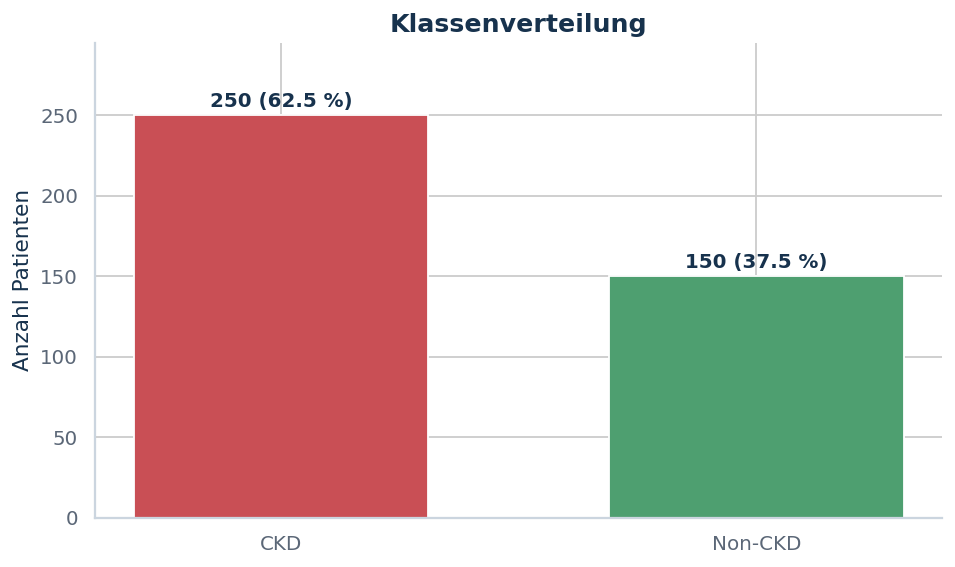

In [3]:
figure = ckd.plot_class_distribution(classes)
plt.show()

display(
    ckd.parameter_dictionary()
    .style.hide(axis="index")
)

## 4. Der entscheidende Fund in der EDA

Fehlende Werte betreffen nicht nur einzelne Patienten oder Parameter. Insgesamt fehlen 1.012 Einzelwerte.

Besonders viele Lücken besitzen `rbc`, `rbcc`, `wbcc`, `pot` und `sod`. Die UCI-Dokumentation erklärt nicht, warum bestimmte Untersuchungen fehlen. Der Missing-Mechanismus lässt sich daher nicht sicher als MCAR, MAR oder MNAR einordnen.

,Fehlend,Fehlend (%),CKD fehlend,CKD fehlend (%),Non-CKD fehlend,Non-CKD fehlend (%)
Parameter,,,,,,
rbc,152,38.0,143,57.2,9,6.0
rbcc,131,32.8,124,49.6,7,4.7
wbcc,106,26.5,99,39.6,7,4.7
pot,88,22.0,83,33.2,5,3.3
sod,87,21.8,82,32.8,5,3.3
pcv,71,17.8,67,26.8,4,2.7
pc,65,16.2,56,22.4,9,6.0
hemo,52,13.0,46,18.4,6,4.0
su,49,12.2,44,17.6,5,3.3


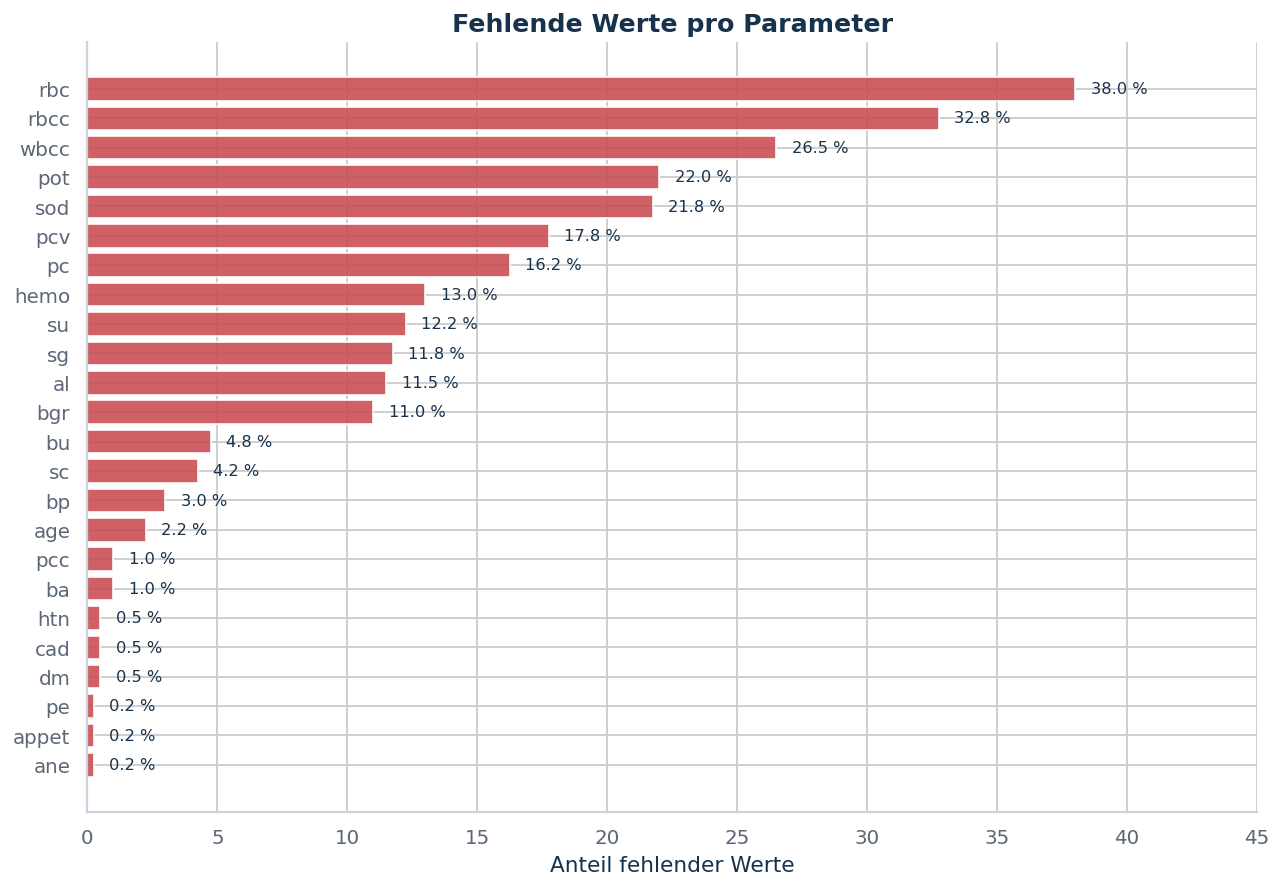

In [4]:
missing = ckd.missingness_summary(total, classes)
display(missing.round(1))

figure = ckd.plot_missingness_by_parameter(missing)
plt.show()

## 5. Complete und Incomplete Cases

Ein **Complete Case** besitzt für alle 24 Eingabeparameter einen Wert. Ein **Incomplete Case** besitzt mindestens einen fehlenden Wert.

Diese Einteilung sagt nichts darüber aus, ob eine Person medizinisch gesund oder krank ist. Im vorliegenden Datensatz sind Vollständigkeit und CKD-Status jedoch auffällig unterschiedlich verteilt.

Missingness,Complete,Incomplete
CKD-Status,,
ckd,43,207
notckd,115,35


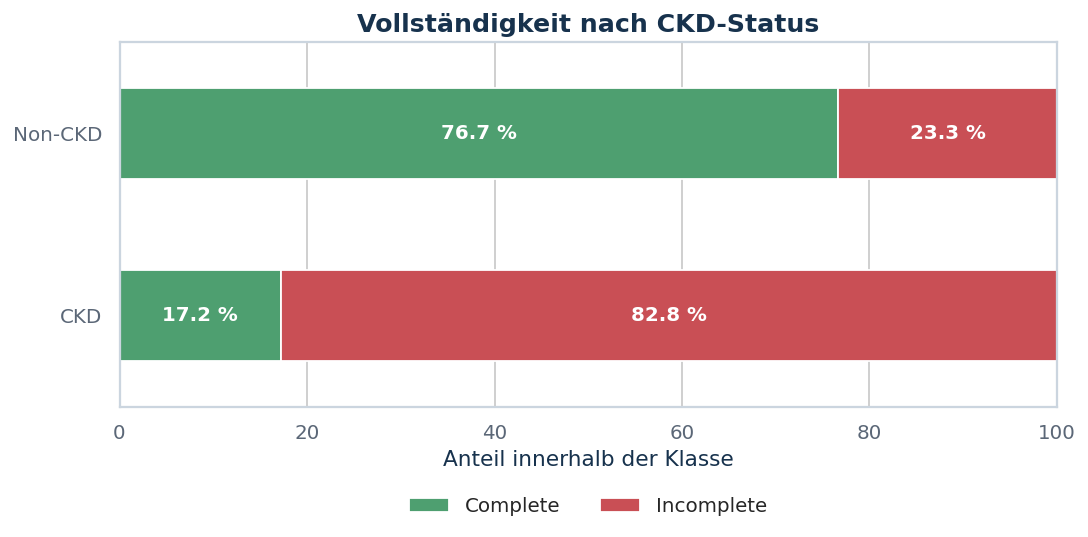

In [5]:
group_table = ckd.missingness_group_table(total, classes)
display(group_table)

figure = ckd.plot_completeness_by_class(group_table)
plt.show()

### Interpretation

- Von 250 CKD-Patienten sind 207 unvollständig: **82,8 %**.
- Von 150 Non-CKD-Patienten sind 35 unvollständig: **23,3 %**.
- Unter den 158 Complete Cases befinden sich nur 43 CKD-Fälle.

Eine reine Complete-Case-Analyse würde 242 Patienten und insbesondere 82,8 % aller CKD-Fälle ausschließen. Dadurch entstünde eine stark veränderte Teilstichprobe.

<div class="warning"><b>Folge:</b> Complete Cases sind hier kein Goldstandard. Sie eignen sich als Sensitivitätsanalyse, repräsentieren aber nicht die ursprüngliche Population.</div>

## 6. Fisher-Exakt-Test

Der Test prüft, ob CKD-Status und Vollständigkeit voneinander unabhängig sind.

\[
H_0: \text{CKD-Status und Missingness sind unabhängig}
\]

\[
H_1: \text{CKD-Status und Missingness sind assoziiert}
\]

Verwendet wird eine zweiseitige Alternative. Vor der Analyse wurde keine konkrete Richtung als alleinige Hypothese festgelegt.

In [6]:
fisher_result = ckd.fisher_missingness_test(group_table)

print(f"Odds Ratio: {fisher_result['Odds Ratio']:.3f}")
print(f"p-Wert: {fisher_result['p-Wert']:.3e}")

Odds Ratio: 0.063
p-Wert: 6.652e-33


Der extrem kleine p-Wert spricht gegen die Unabhängigkeit von Missingness und CKD-Status. Die Odds Ratio von etwa 0,063 ergibt sich aus der gewählten Tabellenrichtung und zeigt eine sehr starke Assoziation.

Der Test erklärt **nicht**, warum Werte fehlen. Er beweist weder MCAR, MAR noch MNAR und zeigt keine Kausalität.

## 7. Beobachtete medizinische Verteilungen

Die folgenden Grafiken verwenden nur tatsächlich beobachtete Messwerte. Fehlende Werte werden nicht imputiert.

Ein einzelner Parameter trennt die Klassen nicht vollständig. Das Modell kann jedoch Schwellenwerte, nichtlineare Beziehungen und Kombinationen mehrerer Parameter nutzen.

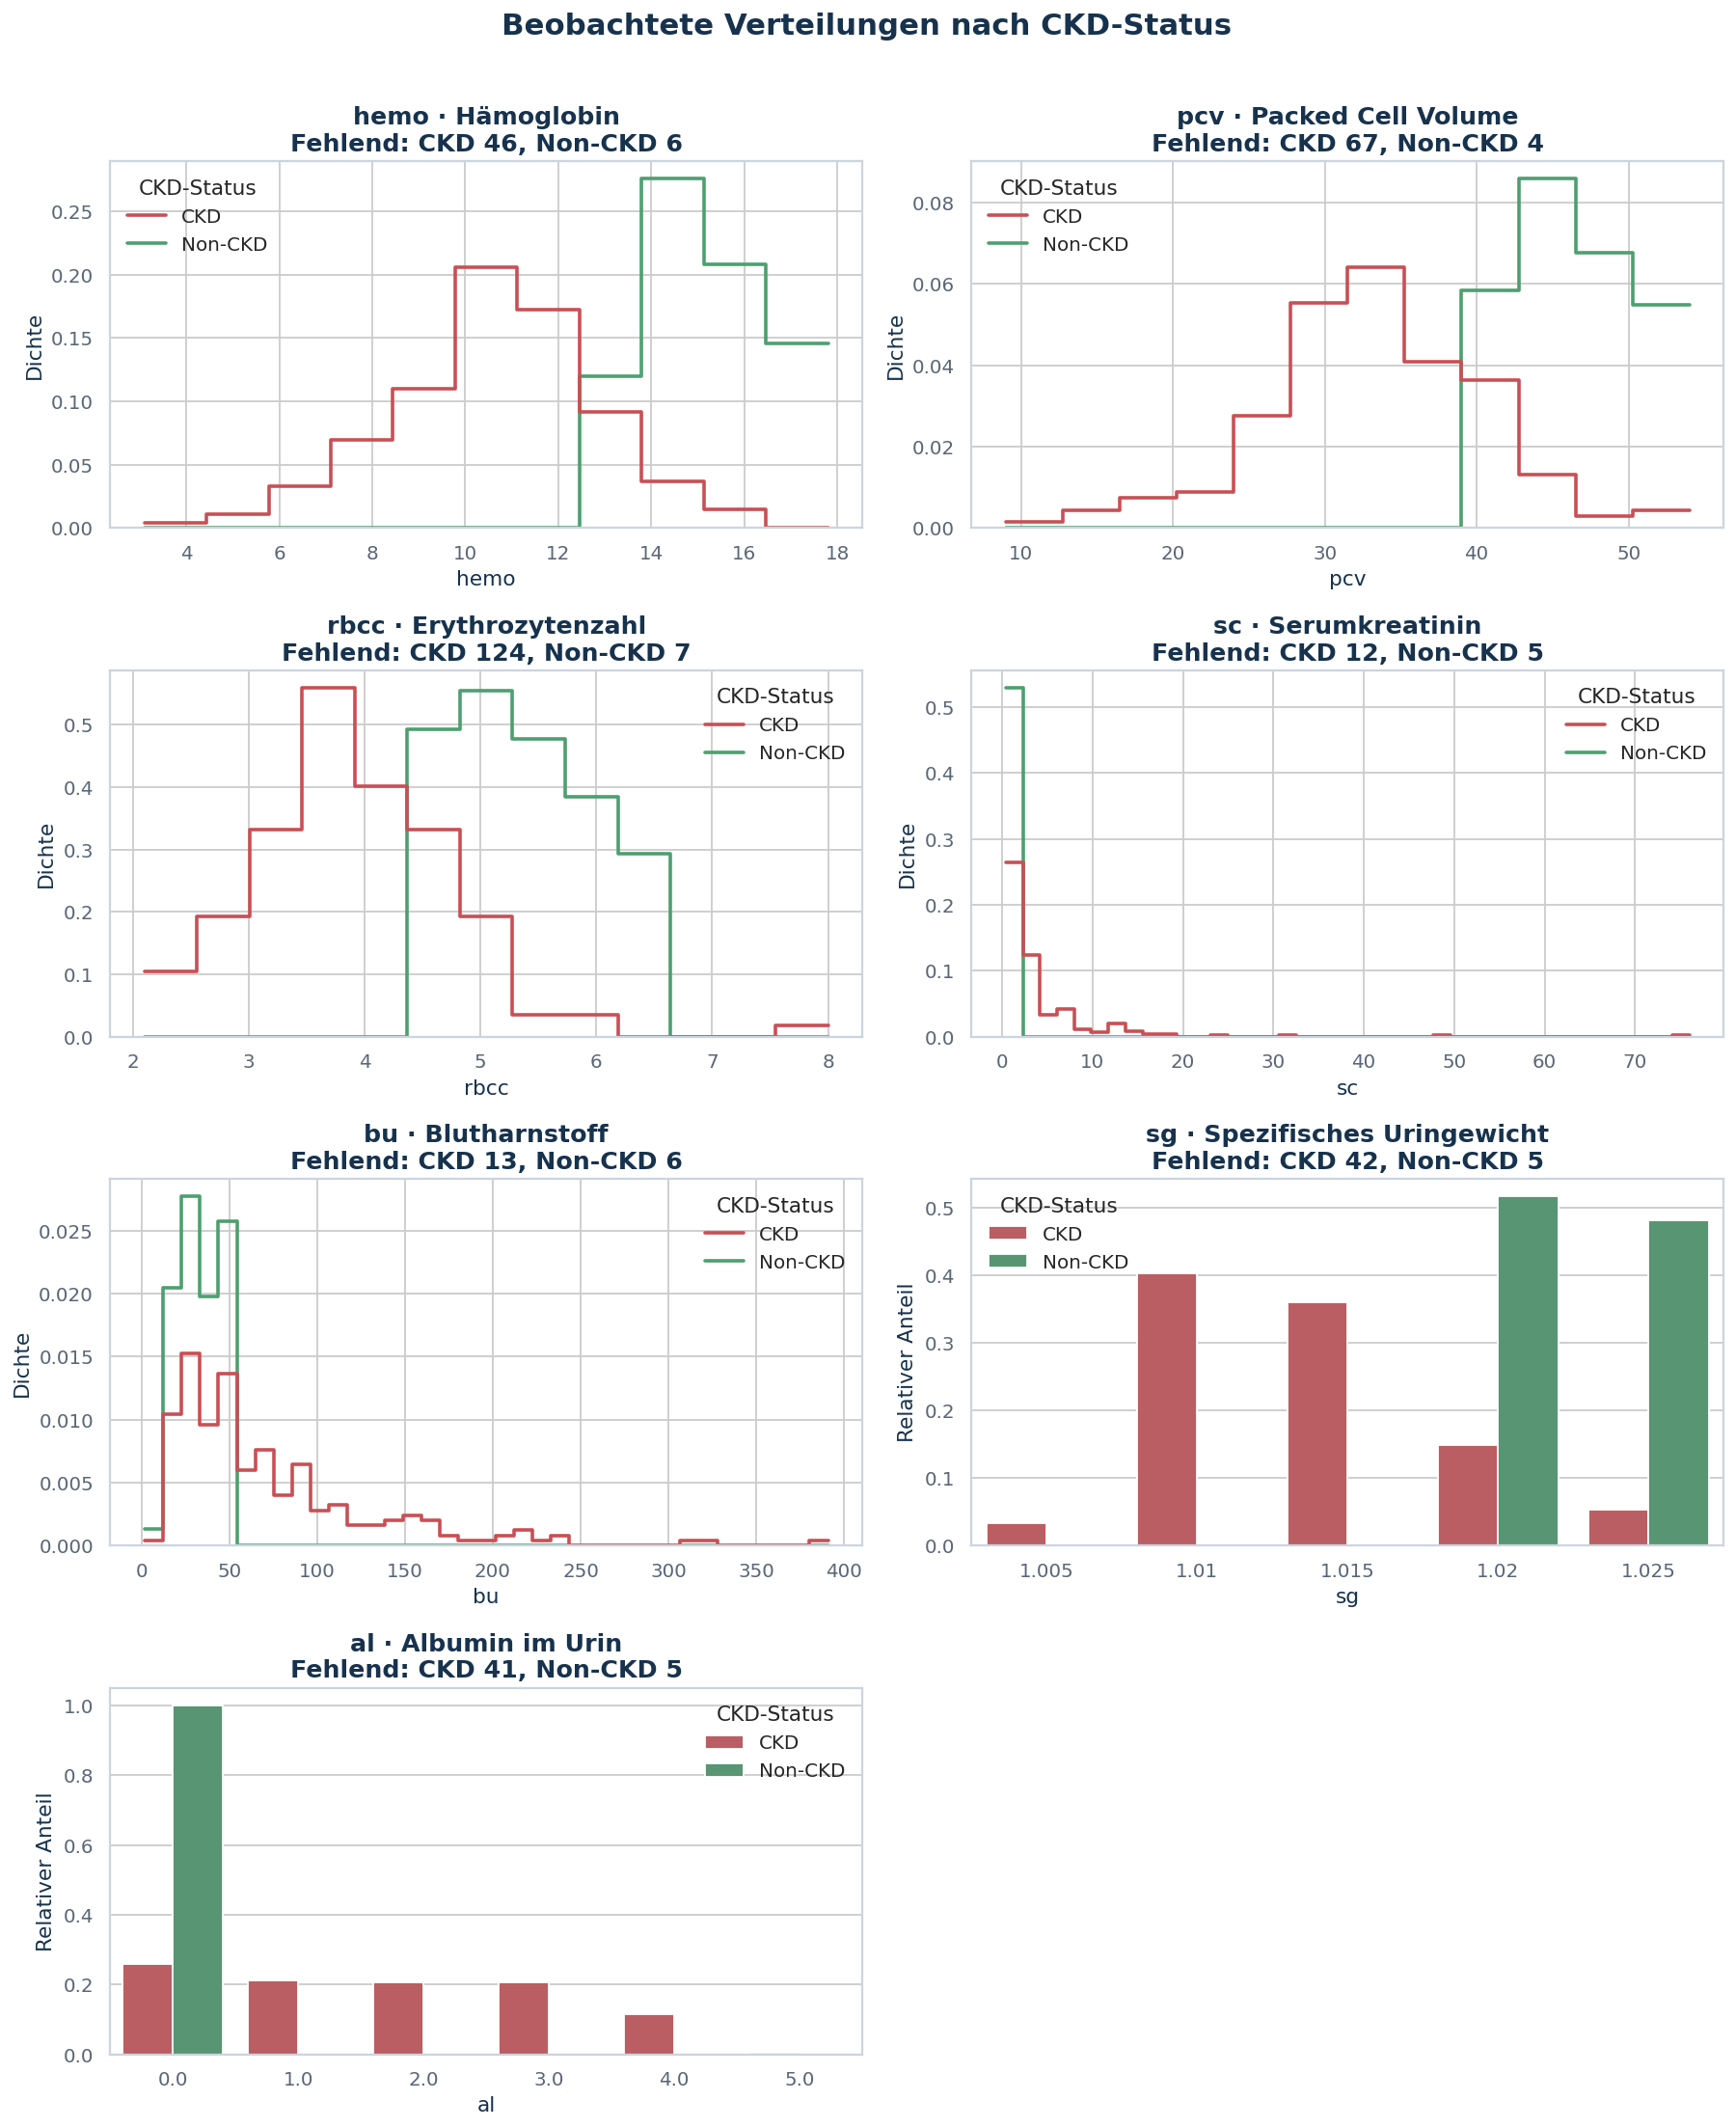

In [7]:
figure = ckd.plot_numeric_distributions(
    total,
    classes,
    columns=["hemo", "pcv", "rbcc", "sc", "bu", "sg", "al"],
    discrete_columns=["sg", "al"],
    columns_per_row=2,
)
plt.show()

In [8]:
for column in ["htn", "dm"]:
    relative = pd.crosstab(
        classes,
        total[column],
        normalize="index",
    ).mul(100).round(1)
    print(f"{column} · {ckd.PARAMETER_LABELS[column]} · Prozent innerhalb der Klasse")
    display(relative)

htn · Bluthochdruck · Prozent innerhalb der Klasse
dm · Diabetes mellitus · Prozent innerhalb der Klasse


htn,no,yes
class,,
ckd,41.2,58.8
notckd,100.0,0.0


dm,no,yes
class,,
ckd,45.2,54.8
notckd,100.0,0.0


### Visuelle Einordnung

Die stärksten Merkmale zeigen keine perfekte eindimensionale Trennung:

- niedrige Hämoglobin-, PCV- und Erythrozytenwerte treten häufiger bei CKD auf
- höhere Kreatinin- und Blutharnstoffwerte sprechen stärker für CKD
- Albumin und spezifisches Uringewicht unterscheiden sich zwischen den Klassen
- in den klinisch unauffälligen Wertebereichen bestehen weiterhin Überlappungen

Die nahezu perfekte Modellleistung kann deshalb nicht mit einem einzelnen Laborwert erklärt werden.

## 8. Modellstrategien

Alle Hauptmodelle werden auf denselben 400 Patienten verglichen. Imputation, Kodierung und Skalierung werden innerhalb jedes Validierungsdurchlaufs ausschließlich aus den 399 Trainingsfällen gelernt.

| Strategie | Umgang mit Missingness | Untersuchungsfrage |
|---|---|---|
| RF Median/Modus | numerisch Median, kategorial Modus | Reicht eine einfache Imputation? |
| RF + Indikatoren | Imputation plus 0/1-Spalten | Liefert das Fehlen selbst Information? |
| RF KNN/Modus | numerisch KNN, kategorial Modus | Ist eine nachbarschaftsbasierte Schätzung besser? |
| RF Native Missing | numerische NaN bleiben erhalten | Wie gut funktioniert direkte Missingness-Verarbeitung? |
| Logistische Regression | Median/Modus, mit und ohne Indikatoren | Reicht eine einfachere lineare Entscheidungsgrenze? |
| Missingness-only | ausschließlich 0/1-Indikatoren | Wie viel verrät nur das Dokumentationsmuster? |

Ein separater Complete-Case-Random-Forest dient als Sensitivitätsanalyse auf einer anderen Population.

## 9. Leave-One-Out-Cross-Validation

Bei 400 Patienten wird das Modell 400-mal trainiert:

1. Eine Person bleibt als Validierungsfall vollständig außen vor.
2. Die übrigen 399 Personen bestimmen Imputation, Kodierung und Modell.
3. Das Modell sagt den ausgelassenen Fall voraus.
4. Jeder Patient wird genau einmal extern zu seinem jeweiligen Trainingslauf vorhergesagt.

LOOCV nutzt den kleinen Datensatz effizient. Sie liefert jedoch keine externe Validierung und kann standortspezifische Muster nicht erkennen.

,Modell,Balanced Accuracy,Fehler
0,RF Median/Modus,0.991,3
1,RF + Indikatoren,0.998,1
2,RF KNN/Modus,0.984,6
3,RF Native Missing,1.000,0
4,LogReg Median/Modus,0.992,–
5,LogReg + Indikatoren,0.998,–
6,LogReg nur Missingness,0.820,–
7,RF nur Missingness,0.833,–


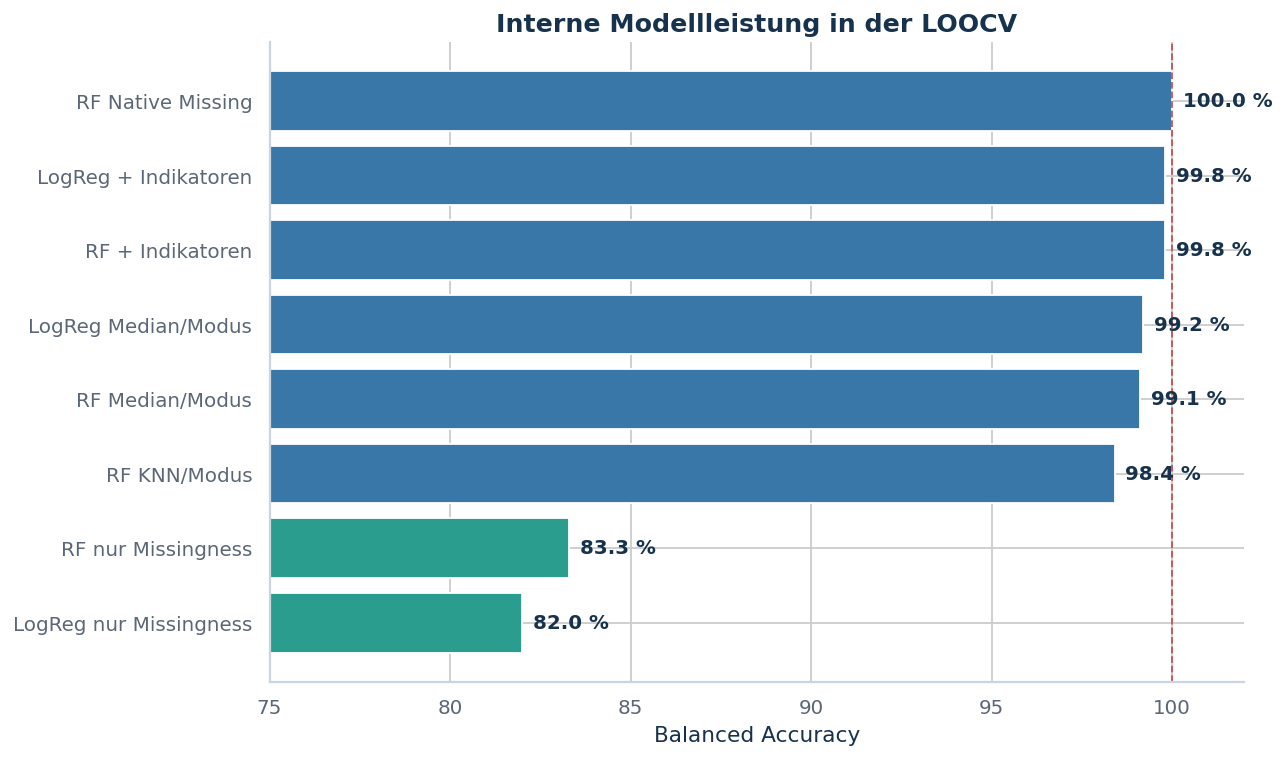

In [9]:
# Eine vollständige Neuberechnung trainiert mehrere tausend Modelle und dauert.
# Für den veröffentlichten Report werden die bereits ausgeführten Ergebnisse geladen.
# Setze den Schalter auf True, um sämtliche LOOCV-Experimente neu zu berechnen.

RUN_EXPENSIVE_LOOCV = False

if RUN_EXPENSIVE_LOOCV:
    model_results, patient_predictions = ckd.run_loocv_benchmark(
        total,
        y,
        n_estimators=300,
        n_jobs=-1,
    )
    missingness_results = ckd.run_missingness_only_loocv(total, y, n_jobs=-1)
    model_results = pd.concat([model_results, missingness_results], ignore_index=True)
else:
    model_results = ckd.reference_loocv_results()

display(model_results.style.format({"Balanced Accuracy": "{:.3f}", "Fehler": "{:.0f}"}, na_rep="–"))

figure = ckd.plot_model_comparison(model_results)
plt.show()

### Was sagen die Ergebnisse?

- Alle Modelle mit medizinischen Messwerten erreichen eine außergewöhnlich hohe interne Leistung.
- RF Native Missing klassifiziert alle 400 LOOCV-Fälle korrekt.
- RF mit Missing-Indikatoren macht nur einen Fehler.
- Median/Modus macht drei, KNN sechs Fehler.
- Die logistische Regression erreicht fast dieselbe Leistung. Die Trennung hängt daher nicht ausschließlich von komplexen Bauminteraktionen ab.
- Missingness-only erreicht 83,3 % Balanced Accuracy. Das Erhebungs- und Dokumentationsmuster enthält somit bereits ein starkes Klassifikationssignal.

<div class="warning"><b>Red Flag:</b> Eine perfekte interne Vorhersage startet die Prüfung. Sie beendet sie nicht. Data Leakage, Dokumentationsmuster und eine sehr spezielle Stichprobe müssen ausgeschlossen beziehungsweise offengelegt werden.</div>

## 10. Complete Cases als Sensitivitätsanalyse

Der Random Forest wurde zusätzlich nur auf den 158 vollständig beobachteten Patienten mit LOOCV bewertet.

| Population | Patienten | CKD-Anteil | Balanced Accuracy | Fehler |
|---|---:|---:|---:|---:|
| Alle Fälle | 400 | 62,5 % | abhängig von Strategie: 0,984–1,000 | 0–6 |
| Complete Cases | 158 | 27,2 % | 0,988 | 1 |

Auch ohne Missingness ist ein starkes medizinisches Signal vorhanden. Dieser Versuch bewertet aber eine selektierte Population mit deutlich verändertem CKD-Anteil und darf nicht als fairer Siegervergleich mit den 400-Fälle-Modellen gelesen werden.

## 11. Statistische Kontrollen der Modellunterschiede

Der McNemar-Test vergleicht gepaarte Vorhersagen derselben Patienten. Er prüft, ob sich zwei Modelle bei ihren Fehlern systematisch unterscheiden.

In [10]:
display(ckd.statistical_summary().style.hide(axis="index"))

print(
    "Kontrollrechnung Native gegen Indikatoren:",
    ckd.mcnemar_exact_from_discordant(1, 0),
)

Kontrollrechnung Native gegen Indikatoren: 1.0


Prüfung,Ergebnis,Aussage
Fisher: Missingness und CKD,"OR = 0,063; p = 6,65 × 10⁻³³",Vollständigkeit und CKD-Status sind stark assoziiert.
McNemar: Native gegen Indikatoren,"0 gegen 1 abweichender Fehler; p = 1,00",Ein abweichender Fall belegt keinen generellen Modellunterschied.
McNemar: Native gegen Median,"p = 0,25",Kein belastbarer Unterschied.
McNemar: Native gegen KNN,"p = 0,031; Holm-korrigiert p = 0,094",Nach Korrektur für mehrere Vergleiche nicht signifikant.
Exaktes 95-%-Intervall für 400/400,"Accuracy ungefähr 0,991 bis 1,000",Perfekte interne Vorhersage garantiert keine perfekte Zukunftsleistung.


Native Missing klassifizierte genau einen Patienten mehr korrekt als das Indikator-Modell. Bei den übrigen 399 Patienten gab es keinen Vorteil. Dieser einzelne abweichende Fall reicht nicht aus, um eine allgemeine Überlegenheit zu belegen.

Auch ein perfektes Ergebnis von 400 aus 400 besitzt Unsicherheit. Das exakte 95-%-Intervall liegt ungefähr zwischen 99,1 % und 100 %. Vor allem sagt dieses Intervall nichts über eine andere Klinik aus.

## 12. Welche Merkmale nutzt der Random Forest?

Die Werte sind relative Feature Importances des Modells mit Median/Modus und Missing-Indikatoren.

Beispiel: 14,5 % für `hemo` bedeutet, dass 14,5 % der im Wald gemessenen Verbesserung der Knotenreinheit diesem Merkmal zugerechnet wurden. Es bedeutet nicht, dass Hämoglobin allein 14,5 % der Patienten klassifiziert.

Merkmal,Importance
hemo,14.5%
pcv,12.4%
sc,10.7%
sg,9.1%
htn,8.4%
rbcc,8.1%
dm,5.6%
al,5.0%
bu,3.1%


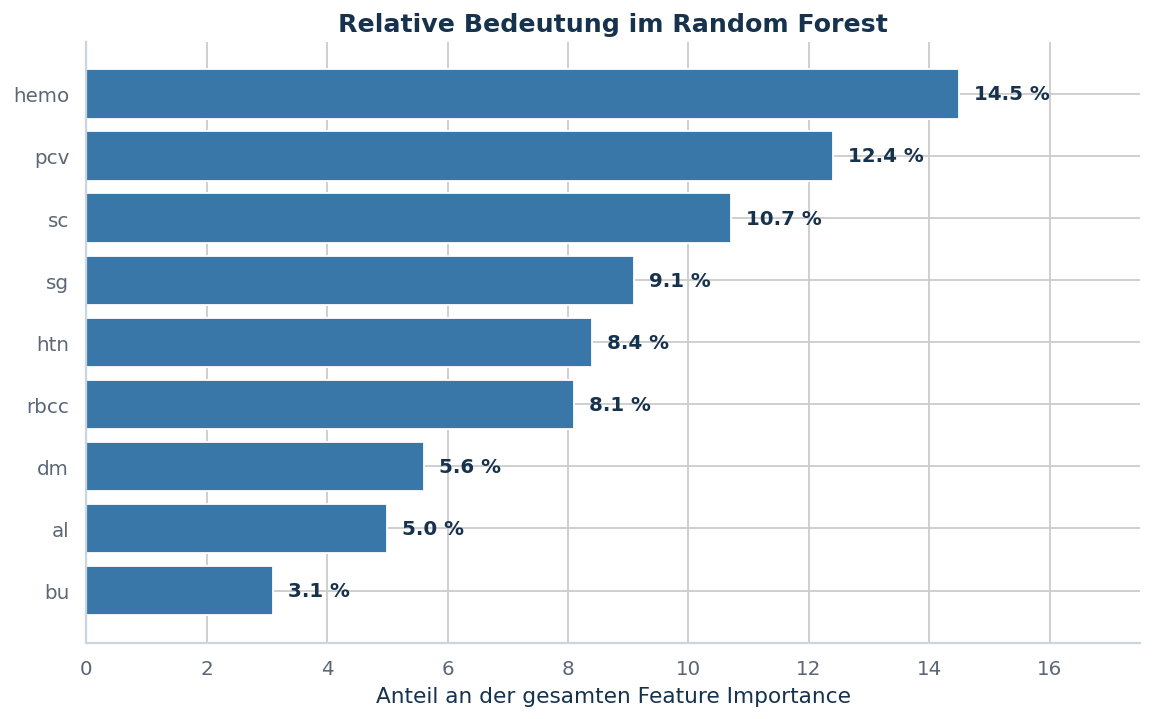

In [11]:
feature_importance = ckd.reference_feature_importance()
display(
    feature_importance.style
    .format({"Importance": "{:.1%}"})
    .hide(axis="index")
)

figure = ckd.plot_feature_importance(feature_importance)
plt.show()

Die gezeigten medizinischen Merkmale bilden zusammen 76,9 % der gesamten Importance ab. Die übrige Importance verteilt sich auf weitere Messwerte, kodierte Kategorien und Missing-Indikatoren.

Besonders das Fehlen von `rbc`, `rbcc`, `pot`, `wbcc` und `sod` lieferte Vorhersageinformation. Diese Information beschreibt nicht nur den Patienten, sondern auch den Erhebungsprozess.

Feature Importance beweist weder Kausalität noch medizinische Eigenständigkeit. Korrelationen können die Importance zwischen ähnlichen Merkmalen wie `hemo`, `pcv` und `rbcc` aufteilen.

## 13. Medizinische Einordnung für Nichtmediziner

Die Modellmerkmale sind medizinisch plausibel. Plausibilität ersetzt jedoch keine externe klinische Validierung.

In [12]:
display(
    ckd.medical_interpretation_table()
    .style.hide(axis="index")
)

Merkmal,Muster bei CKD,Einfache medizinische Erklärung,Bedeutung
sc · Kreatinin,höher,Gesunde Nieren filtern Kreatinin aus dem Blut. Ein hoher Wert kann auf eine eingeschränkte Nierenfunktion hinweisen.,zentral
al · Albumin im Urin,höher,Albumin gelangt normalerweise kaum in den Urin. Größere Mengen können auf geschädigte Nierenfilter hinweisen.,zentral
"hemo, pcv, rbcc",niedriger,Erkrankte Nieren können zu wenig Signal für die Bildung roter Blutkörperchen geben. Dadurch kann Blutarmut entstehen.,plausible Folge
"htn, dm",häufiger,Bluthochdruck und Diabetes können die feinen Blutgefäße der Nieren langfristig schädigen.,Risikofaktoren
bu · Blutharnstoff,höher,"Wenn die Nieren schlechter arbeiten, kann sich mehr Harnstoff im Blut ansammeln. Andere Faktoren beeinflussen den Wert ebenfalls.",unterstützend
sg · Uringewicht,niedriger,"Der Wert zeigt, wie gut die Nieren den Urin konzentrieren. Ein niedriger Wert kann auf eine eingeschränkte Konzentrationsfähigkeit hinweisen.",ergänzend


Keiner dieser Werte beweist allein eine chronische Nierenerkrankung. Medizinische Diagnostik berücksichtigt das gemeinsame Muster, den zeitlichen Verlauf und weitere klinische Untersuchungen.

## 14. Grenzen der Analyse

1. **Kleine Stichprobe:** 400 Patienten reichen für eine methodische Demonstration, aber nicht für eine belastbare klinische Generalisierung.
2. **Ein Erhebungsort:** Die Daten stammen aus einem Krankenhaus und einem kurzen Zeitraum. Klinikprozesse können Teil des Signals sein.
3. **Unklarer Missing-Mechanismus:** Die Dokumentation erklärt nicht, warum Untersuchungen fehlen.
4. **Keine externe Validierung:** LOOCV prüft nur die interne Übertragbarkeit zwischen diesen 400 Fällen.
5. **Keine unabhängige Kohorte:** Es fehlen Daten aus anderen Kliniken, Regionen, Geräten und Zeiträumen.
6. **Feature Importance ist modellabhängig:** Korrelierte Merkmale teilen sich Bedeutung und erlauben keine kausale Interpretation.

Für einen klinisch belastbaren Test wären wiederholte Erhebungen in mehreren Krankenhäusern mit vergleichbarem Laborprotokoll und unabhängiger externer Validierung erforderlich.

## 15. Endinterpretation

### Was die Daten zeigen

Die medizinischen Parameter enthalten ein starkes internes CKD-Signal. Random Forest und logistische Regression klassifizieren die Patienten innerhalb dieses Datensatzes nahezu perfekt.

### Warum das Ergebnis kritisch bleibt

Missingness ist stark mit dem CKD-Status verbunden. Ein Modell, das ausschließlich das Fehlen von Untersuchungen sieht, erreicht bereits 83,3 % Balanced Accuracy. Die vollständigen Modelle können deshalb neben Krankheitsmustern auch den Dokumentationsprozess lernen.

### Was ein gutes Modell zusätzlich leisten muss

Ein klinisch brauchbares Modell muss in anderen Krankenhäusern, Zeiträumen und Populationen geprüft werden. Erst eine externe Validierung zeigt, ob es die Krankheit und nicht nur die Besonderheiten dieses Datensatzes erkennt.

> **Der Datensatz ist für eine methodische Analyse sehr lehrreich. Für eine allgemeine medizinische Anwendung reicht seine Beweislage nicht aus.**

## 16. Veröffentlichung auf GitHub und Kaggle

Die Analyse kann veröffentlicht werden. Der UCI-Datensatz steht unter **CC BY 4.0** und darf mit korrekter Namensnennung geteilt und bearbeitet werden.

Bei einer Veröffentlichung sollten sichtbar enthalten sein:

- Originalquelle und DOI
- Lizenz CC BY 4.0
- Zitation der Datensatzautoren
- Hinweis, dass du die Analyse erstellt hast, aber nicht die Rohdaten erhoben hast
- methodische und klinische Einschränkungen

Empfohlene Zitation:

> Rubini, L., Soundarapandian, P., and Eswaran, P. (2015). Chronic Kidney Disease [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C5G020

Auf Kaggle kann entweder die CSV mit dieser Attribution als Datensatz veröffentlicht oder das Notebook mit Verweis auf die UCI-Quelle bereitgestellt werden. Ein Notebook mit sauberer Quellenangabe vermeidet den Eindruck, die Daten seien selbst erhoben worden.